<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1742 | Val: 489 | Test: 276


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 4, accumulation steps = 30 (effective batch size ≈ 120, tuned value = 121)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 30 micro-batches per optimizer step (effective batch size ≈ micro_batch x 30).
[ResNet-50] Epoch   1/100 | LR: 2.68e-05 | train loss 1.3702 acc 0.405 | val loss 1.3078 acc 0.421 *
[ResNet-50] Epoch   2/100 | LR: 2.68e-05 | train loss 1.2736 acc 0.418 | val loss 1.1260 acc 0.421 *
[ResNet-50] Epoch   3/100 | LR: 2.68e-05 | train loss 1.2028 acc 0.481 | val loss 1.0540 acc 0.566 *
[ResNet-50] Epoch   4/100 | LR: 2.68e-05 | train loss 1.1651 acc 0.526 | val loss 1.0497 acc 0.583 *
[ResNet-50] Epoch   5/100 | LR: 2.68e-05 | train loss 1.1442 acc 0.562 | val loss 1.0520 acc 0.544
[ResNet-50] Epoch   6/100 | LR: 2.68e-05 | train loss 1.0923 acc 0.577 | val loss 0.9671 acc 0.575 *
[ResNet-50] Epoch   7/100 | LR: 2.68e-05 | train loss 1.0571 acc 0.569 | val loss 0.8836 acc 0.616 *
[ResNet-50] Epoch   8/100 | LR: 2.68e-05 | train loss 1.0296 acc 0.587 | val loss 0.8698 acc 0.636 *
[ResNet-50] Epoch   9/100 | LR: 2.68e-05 | train loss 0.9846 acc 0.595 | v

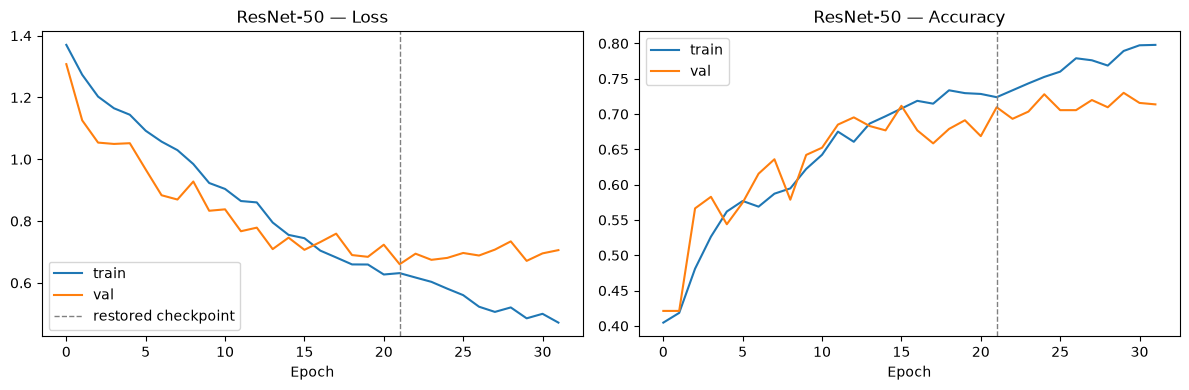

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.746


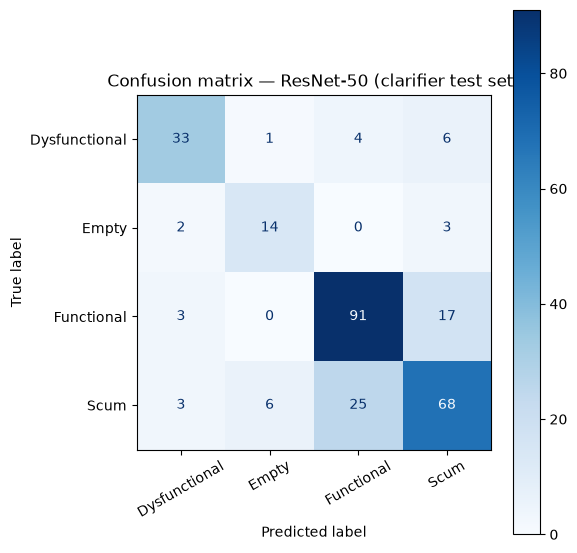

               precision    recall  f1-score   support

Dysfunctional      0.805     0.750     0.776        44
        Empty      0.667     0.737     0.700        19
   Functional      0.758     0.820     0.788       111
         Scum      0.723     0.667     0.694       102

     accuracy                          0.746       276
    macro avg      0.738     0.743     0.740       276
 weighted avg      0.747     0.746     0.745       276



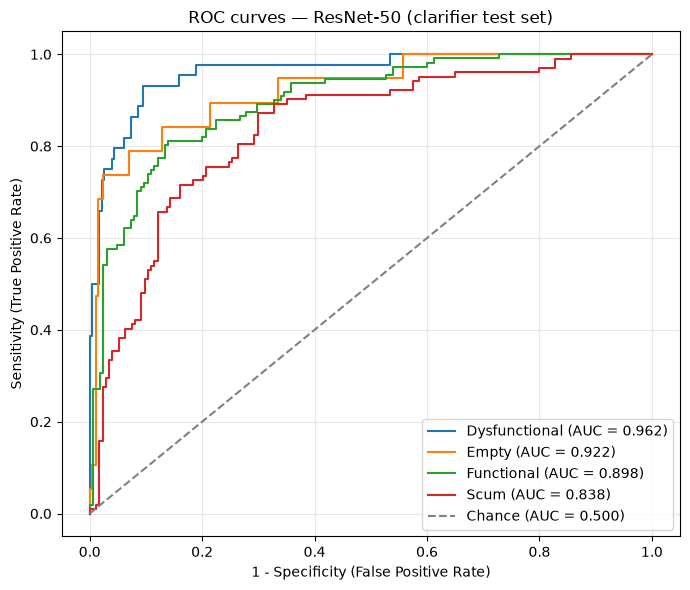

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.962
  Empty          : 0.922
  Functional     : 0.898
  Scum           : 0.838

Mean AUC: 0.905


(np.float64(0.7463768115942029),
 {'Dysfunctional': 0.961794670846395,
  'Empty': 0.9223837804628302,
  'Functional': 0.8981162981162981,
  'Scum': 0.8377845391029975})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/results_resnet50.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
